# On the reproducibility of IPCC digital products

The scientific integrity, reliability, transparency, confidence and trustworthiness of climate change assessments depends on clear provenance and reproducibility, as well as on complementary products and services that help assess and communicate their findings. While IPCC Assessment Reports evaluate the state of knowledge on climate change, attention to provenance and reproducibility has only emerged relatively recently.

## The AR6 Atlas

The Atlas has been both a contributing chapter of the AR6 and a web application that enables users to visualize global and regional climate products directly in a web browser. Ensuring strong provenance and reproducibility of both the underlying data and the services built on top of the Interactive Atlas is essential for maintaining the integrity and transparency of the climate model outputs and the information it presents.

This notebook traces the climate products displayed in the Atlas back to their original sources and aims to illustrate both the opportunities and challenges related to provenance and reproducibility faced by IPCC Assessment Reports and their companion digital products.

We will look at three concrete and different MIPs: **CMIP6**, **CMIP5** and **CORDEX**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## CMIP6

We load the various sources of information. Note that datasets included in the Interactive Atlas have been cataloged to provide users with sufficient provenance and reproducibility, aligning with the requirements of IPCC digital products.

We will also include other repositories into our analysis.

- https://console.cloud.google.com/marketplace/product/noaa-public/cmip6
- https://registry.opendata.aws/cmip6/

In [2]:
atlas = pd.read_csv("inventories/atlas-cmip6.txt", header=None).rename({0: "instance_id"}, axis=1)
atlas = atlas.join(atlas["instance_id"].str.split(".", expand=True).rename({
    0: "project",
    1: "activity_id",
    2: "institution_id",
    3: "source_id",
    4: "experiment_id",
    5: "variant_label",
    6: "table_id",
    7: "variable_id",
    8: "grid_label",
    9: "version",
    }, axis=1))

In [3]:
atlas = pd.concat([
    #pd.read_csv("inventories/atlas-cmip6.txt", header=None, names=["instance_id"]),
    pd.read_csv("inventories/atlas-cmip6-html.txt", header=None, names=["instance_id"]),
    pd.read_csv("inventories/atlas-cmip6-tsu.txt", header=None, names=["instance_id"])],
    axis=0).drop_duplicates()
atlas = atlas.join(atlas["instance_id"].str.split(".", expand=True).rename({
    0: "project",
    1: "activity_id",
    2: "institution_id",
    3: "source_id",
    4: "experiment_id",
    5: "variant_label",
    6: "table_id",
    7: "variable_id",
    8: "grid_label",
    9: "version",
    }, axis=1))

Variables included in the atlas inventory.

In [4]:
atlas[["variable_id", "table_id"]].drop_duplicates()

,variable_id,table_id
0,prsn,Amon
1,sfcWind,Amon
2,tos,Omon
3,siconc,SImon
4,pr,day
5,psl,day
6,tas,day
16,tasmax,day
17,tasmin,day
318,tos,3hr


In [5]:
esgf  = pd.read_json("inventories/esgf-cmip6.json.zip", lines=True)

wdc = pd.read_csv("inventories/wdc-cmip6-20260319.txt", names=["instance_id"])

pangeo_gcs = pd.read_csv("inventories/pangeo-cmip6-gcs-v20251218.csv.zip")
pangeo_aws = pd.read_csv("inventories/pangeo-cmip6-aws-v20251218.csv.zip")

Distribution of datasets per variable.

<Axes: xlabel='variable_id'>

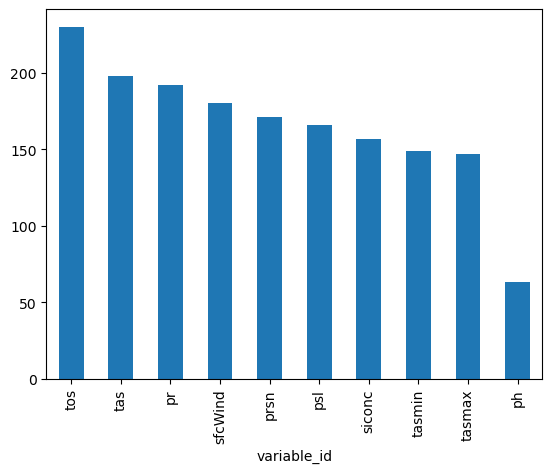

In [6]:
atlas["variable_id"].value_counts().plot.bar()

Compute the `instance_id` for Pangeo inventories to enable comparison and identification of matching datasets across different inventories.

In [7]:
pangeo_gcs["instance_id"] = pangeo_gcs.apply(lambda x: '.'.join([
        "CMIP6",
        x["activity_id"],
        x["institution_id"],
        x["source_id"],
        x["experiment_id"],
        x["member_id"],
        x["table_id"],
        x["variable_id"],
        x["grid_label"],
        "v" + str(x["version"]),
    ]),
    axis=1)

pangeo_aws["instance_id"] = pangeo_aws.apply(lambda x: '.'.join([
        "CMIP6",
        x["activity_id"],
        x["institution_id"],
        x["source_id"],
        x["experiment_id"],
        x["member_id"],
        x["table_id"],
        x["variable_id"],
        x["grid_label"],
        "v" + str(x["version"]),
    ]),
    axis=1)

Identify matching datasets. Note that in the ESGF, a **dataset** corresponds to a collection of NetCDF files representing the time series of a single variable, produced by a single model and model run, at a specified time frequency.

In [8]:
print("Atlas datasets: {}\nESGF datasets: {}\nWDC datasets: {}\nPangeo GCS datasets: {}\nPangeo AWS datasets: {}".format(
    len(atlas),
    atlas["instance_id"].isin(esgf["instance_id"].values).sum(),
    atlas["instance_id"].isin(wdc["instance_id"].values).sum(),
    atlas["instance_id"].isin(pangeo_gcs["instance_id"].values).sum(),
    atlas["instance_id"].isin(pangeo_aws["instance_id"].values).sum()))

Atlas datasets: 1653
ESGF datasets: 1653
WDC datasets: 1445
Pangeo GCS datasets: 1429
Pangeo AWS datasets: 1458


### The role of replicas in the ESGF

The ESGF allows research centers operating Tier 1 nodes to host replicas of datasets from Tier 2 nodes, improving resilience and reducing the risk of data loss. We can examine how many datasets are available as a result of this replication feature within the ESGF.

In [9]:
print("Atlas datasets: {}\nESGF datasets (replicas included): {}\nESGF datasets (replicas excluded): {}\nWDC datasets: {}\nPangeo GCS datasets: {}\nPangeo AWS datasets: {}".format(
    len(atlas),
    atlas["instance_id"].isin(esgf["instance_id"].values).sum(),
    atlas["instance_id"].isin(esgf[~esgf["replica"]]["instance_id"].values).sum(),
    atlas["instance_id"].isin(wdc["instance_id"].values).sum(),
    atlas["instance_id"].isin(pangeo_gcs["instance_id"].values).sum(),
    atlas["instance_id"].isin(pangeo_aws["instance_id"].values).sum()))

Atlas datasets: 1653
ESGF datasets (replicas included): 1653
ESGF datasets (replicas excluded): 1601
WDC datasets: 1445
Pangeo GCS datasets: 1429
Pangeo AWS datasets: 1458


Include also other different versions that might have been publish after removing the version in the Atlas inventories.

In [10]:
atlas["master_id"] = atlas["instance_id"].str.split(".").str[:-1].str.join(".")
wdc["master_id"] = wdc["instance_id"].str.split(".").str[:-1].str.join(".")
pangeo_gcs["master_id"] = pangeo_gcs["instance_id"].str.split(".").str[:-1].str.join(".")
pangeo_aws["master_id"] = pangeo_aws["instance_id"].str.split(".").str[:-1].str.join(".")

print("Atlas datasets: {}\nESGF datasets (replicas included): {}\nESGF datasets (replicas excluded): {}\nWDC datasets: {}\nPangeo GCS datasets: {}\nPangeo AWS datasets: {}".format(    len(atlas),
    atlas["master_id"].isin(esgf["master_id"].values).sum(),
    atlas["master_id"].isin(esgf[~esgf["replica"]]["master_id"].values).sum(),
    atlas["master_id"].isin(wdc["master_id"].values).sum(),
    atlas["master_id"].isin(pangeo_gcs["master_id"].values).sum(),
    atlas["master_id"].isin(pangeo_aws["master_id"].values).sum()))

Atlas datasets: 1653
ESGF datasets (replicas included): 1653
ESGF datasets (replicas excluded): 1652
WDC datasets: 1458
Pangeo GCS datasets: 1491
Pangeo AWS datasets: 1530


It is evident that without replication mechanisms, data availability within the ESGF would be significantly compromised. The necessity for data centers capable of reliably storing data, using mechanisms to prevent data loss, such as tape storage, cannot be overstated.

We can now examine where these replicas are hosted and provide an overview of where data actually resides within the federation. We also present the storage burden faced by each data center.

In [11]:
esgf[["data_node", "title"]].drop_duplicates().groupby("data_node").count().join(
    esgf[["data_node", "title", "replica"]].drop_duplicates(["data_node", "title"])[["data_node", "replica"]].groupby("data_node").sum()).join(
    esgf[["data_node", "size"]].groupby("data_node").sum().rename({"size": "size (GiB)"}, axis=1)/2**30).sort_values(
    "size (GiB)", ascending=False)

,title,replica,size (GiB)
data_node,,,
esgf-node.ornl.gov,1545,1545,5248.681567
esgf.ceda.ac.uk,1525,1439,5234.193939
esgf3.dkrz.de,1424,1181,4024.788098
esgf-data04.diasjp.net,1263,1263,3899.196417
eagle.alcf.anl.gov,1429,1429,3704.517838
esgf.nci.org.au,1277,1187,3119.711597
esg-dn1.nsc.liu.se,63,0,1357.370410
esg-dn2.nsc.liu.se,53,0,1094.392349
esg1.umr-cnrm.fr,143,0,654.590806


### TSU provided information

In case of the DDC at DKRZ, the numbers are not that much supporting the idea that the DDC ensures long-term data availability. Double-check if we find the 1480 datasets in the information that the TSU provided to DKRZ in addition.

https://github.com/IPCC-WG1/DDC-AR6-CMIP6-Data-Archival/blob/main/Metadata_Conformance/input_20220125/cmip6_datasets_ch13.json

In [12]:
ch13 = pd.read_csv("inventories/cmip6_datasets_ch13_input_20220125.csv", header=None, names=["instance_id", "handle"])
ch13_figures = pd.read_csv("inventories/cmip6_datasets_ch13_input_figures_20220125.csv", header=None, names=["instance_id", "fig"])

# fixes to TSU inventory
ch13["instance_id"] = ch13["instance_id"].str.replace("ScenarioMIP AerChemMIP", "ScenarioMIP")

# instance_id
ch13["instance_id"] = ch13["instance_id"].str.replace(r'\.(\d+)$', r'.v\1', regex=True)
ch13_figures["instance_id"] = ch13_figures["instance_id"].str.replace(r'\.(\d+)$', r'.v\1', regex=True)

# master_id
ch13["master_id"] = ch13["instance_id"].str.split(".").str[:-1].str.join(".")
ch13_figures["master_id"] = ch13_figures["instance_id"].str.split(".").str[:-1].str.join(".")

We can get an idea of the number of datasets used in each figure.

In [13]:
ch13_figures.groupby("fig").count().rename({"instance_id": "datasets"}, axis=1)

,datasets,master_id
fig,,
Atlas.12,133,133
Atlas.13,265,265
Atlas.15,68,68
Atlas.16,265,265
Atlas.17,265,265
Atlas.21,265,265
Atlas.22,265,265
Atlas.24,265,265
Atlas.26,265,265


Locate datasets matching the exact same version.

In [14]:
print("TSU ch13 datasets: {}\nWDC datasets: {}\nESGF datasets (replicas included): {}\nESGF datasets (replicas excluded): {}\nPangeo GCS datasets: {}\nPangeo AWS datasets: {}".format(
    len(ch13["instance_id"].unique()),
    ch13["instance_id"].isin(wdc["instance_id"].values).sum(),
    ch13["instance_id"].isin(esgf["instance_id"].values).sum(),
    ch13["instance_id"].isin(esgf[~esgf["replica"]]["instance_id"].values).sum(),
    ch13["instance_id"].isin(pangeo_gcs["instance_id"].values).sum(),
    ch13["instance_id"].isin(pangeo_aws["instance_id"].values).sum()))

TSU ch13 datasets: 396
WDC datasets: 394
ESGF datasets (replicas included): 396
ESGF datasets (replicas excluded): 382
Pangeo GCS datasets: 354
Pangeo AWS datasets: 364


Locate datasets matching any version available.

In [15]:
print("TSU ch13 datasets: {}\nWDC datasets: {}\nESGF datasets (replicas included): {}\nESGF datasets (replicas excluded): {}\nPangeo GCS datasets: {}\nPangeo AWS datasets: {}".format(
    len(ch13["master_id"]),
    ch13["master_id"].isin(wdc["master_id"].values).sum(),
    ch13["master_id"].isin(esgf["master_id"].values).sum(),
    ch13["master_id"].isin(esgf[~esgf["replica"]]["master_id"].values).sum(),
    ch13["master_id"].isin(pangeo_gcs["master_id"].values).sum(),
    ch13["master_id"].isin(pangeo_aws["master_id"].values).sum()))

TSU ch13 datasets: 396
WDC datasets: 394
ESGF datasets (replicas included): 396
ESGF datasets (replicas excluded): 396
Pangeo GCS datasets: 373
Pangeo AWS datasets: 383


Obtain the identifiers of missing datasets.

In [16]:
missing = ch13[~ch13["instance_id"].isin(wdc["instance_id"].values)]["instance_id"].values
len(missing)

2

In [17]:
missing

<StringArray>
['CMIP6.ScenarioMIP.NCAR.CESM2.ssp126.r1i1p1f1.Omon.tos.gr.v20190730', 'CMIP6.ScenarioMIP.NCAR.CESM2.ssp585.r1i1p1f1.Omon.tos.gr.v20190730']
Length: 2, dtype: str

Which figures are affected because of missing datasets.

In [18]:
sorted(list(ch13_figures[ch13_figures["instance_id"].isin(missing)]["fig"].unique()))

['Atlas.15', 'Atlas.28']

### Interactive Atlas inventories and TSU ch13

We aim to check if datasets provided to TSU are not found in the inventories of the Atlas.

In [19]:
not_in_atlas = ch13[~ch13["instance_id"].isin(atlas["instance_id"].values)]
not_in_atlas

,instance_id,handle,master_id


### Checksums

We aim to check if checksums match across data nodes in the federation.

In [20]:
esgf_files = pd.read_json("inventories/esgf-cmip6-files.json.zip", lines=True)

How many "unique" files are in the inventory?

In [21]:
len(esgf_files["instance_id"].unique())

58964

Are there any different checksums? Alledgelly, any combination of `title` and `version` should have an unique version.

In [22]:
checksum_counts = esgf_files[["title", "version", "checksum"]].groupby(["title", "version"]).nunique().sort_values(by="checksum", ascending=True).reset_index()
checksum_counts[checksum_counts["checksum"]>1].sort_values(["title", "version"])

,title,version,checksum
74969,ph_Omon_NorESM2-MM_ssp585_r1i1p1f1_gr_201501-2...,1,2
74977,ph_Omon_NorESM2-MM_ssp585_r1i1p1f1_gr_202101-2...,1,2
74973,ph_Omon_NorESM2-MM_ssp585_r1i1p1f1_gr_203101-2...,1,2
74981,ph_Omon_NorESM2-MM_ssp585_r1i1p1f1_gr_204101-2...,1,2
75012,ph_Omon_NorESM2-MM_ssp585_r1i1p1f1_gr_205101-2...,1,2
...,...,...,...
75437,tos_Omon_EC-Earth3-Veg_historical_r1i1p1f1_gn_...,1,2
75143,tos_Omon_KACE-1-0-G_ssp245_r2i1p1f1_gr_201501-...,20200130,2
75147,tos_Omon_KACE-1-0-G_ssp370_r2i1p1f1_gr_201501-...,20200130,2
75154,tos_Omon_KIOST-ESM_historical_r1i1p1f1_gr1_185...,1,2


How many files have different checksums?

In [23]:
checksum_counts[checksum_counts["checksum"]>1]["title"].unique().shape

(1961,)

## CMIP5

CMIP5 serves a good example to how much data is still available after some years of no activity in the phase of CMIP.

In [24]:
cmip5_atlas = pd.read_csv("inventories/atlas-cmip5.txt", names=["instance_id"])
cmip5_wdc = pd.read_csv("inventories/wdc-cmip5-20260319.txt", names=["instance_id"])
cmip5_esgf = pd.read_json("inventories/esgf-cmip5.json.zip", lines=True)

cmip5_atlas["instance_id"] = cmip5_atlas["instance_id"].str.replace("CMIP5", "cmip5")

In [25]:
print("Atlas datasets: {}\nESGF datasets (replicas included): {}\nESGF datasets (replicas excluded): {}\nWDC datasets: {}".format(
    len(cmip5_atlas),
    cmip5_atlas["instance_id"].isin(cmip5_esgf["instance_id"].values).sum(),
    cmip5_atlas["instance_id"].isin(cmip5_esgf[~cmip5_esgf["replica"]]["instance_id"].values).sum(),
    cmip5_atlas["instance_id"].isin(cmip5_wdc["instance_id"].values).sum(),))

Atlas datasets: 174
ESGF datasets (replicas included): 106
ESGF datasets (replicas excluded): 67
WDC datasets: 72


Include also datasets that have some other version available.

In [26]:
cmip5_atlas["master_id"] = cmip5_atlas["instance_id"].str.split(".").str[:-1].str.join(".")
cmip5_wdc["master_id"] = cmip5_wdc["instance_id"].str.split(".").str[:-1].str.join(".")

print("Atlas datasets: {}\nESGF datasets (replicas included): {}\nESGF datasets (replicas excluded): {}\nWDC datasets: {}".format(
    len(cmip5_atlas),
    cmip5_atlas["master_id"].isin(cmip5_esgf["master_id"].values).sum(),
    cmip5_atlas["master_id"].isin(cmip5_esgf[~cmip5_esgf["replica"]]["master_id"].values).sum(),
    cmip5_atlas["master_id"].isin(cmip5_wdc["master_id"].values).sum(),))

Atlas datasets: 174
ESGF datasets (replicas included): 167
ESGF datasets (replicas excluded): 127
WDC datasets: 138


Does the WDC support missing datasets from the ESGF?

In [27]:
missing_esgf_cmip5 = cmip5_atlas[~cmip5_atlas["instance_id"].isin(cmip5_esgf["instance_id"].values)]["instance_id"]
print(f"{len(missing_esgf_cmip5)} datasets missing from the ESGF")
print(f"{missing_esgf_cmip5.isin(cmip5_wdc['instance_id'].values).sum()} datasets missing from ESGF available at WDC")

68 datasets missing from the ESGF
2 datasets missing from ESGF available at WDC


Let's obtain some information about missing datasets.

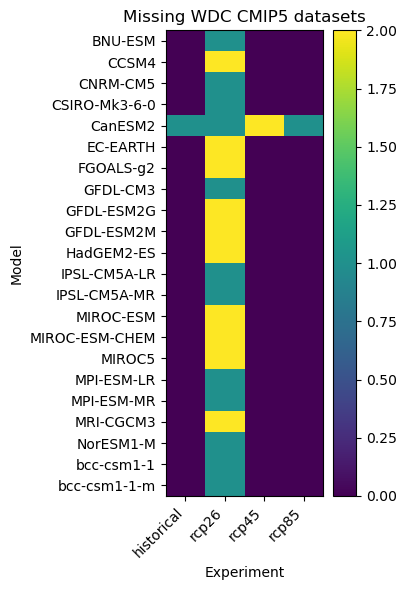

In [28]:
missing_wdc = cmip5_atlas[~cmip5_atlas["master_id"].isin(cmip5_wdc["master_id"].values)]["master_id"].str.split(".", expand=True).rename({
    0: "project", 1: "product", 2: "institute", 3: "model", 4: "experiment", 5: "frequency", 6: "realm", 7:"table", 8: "ensemble",}, axis=1)

heatmap_data = (
    missing_wdc
    .groupby(["model", "experiment"])
    .size()
    .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(4, 6))
cax = ax.imshow(heatmap_data, aspect='auto')

fig.colorbar(cax)
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=45, ha='right')
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
ax.set_xlabel("Experiment")
ax.set_ylabel("Model")
ax.set_title("Missing WDC CMIP5 datasets")

plt.savefig("cmip5-missing-datasets-wdc.pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()

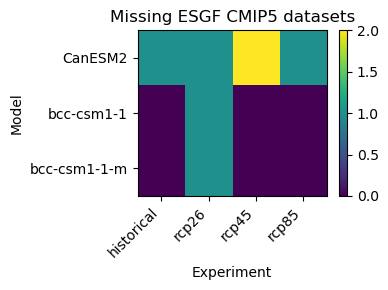

In [29]:
missing_esgf = cmip5_atlas[~cmip5_atlas["master_id"].isin(cmip5_esgf["master_id"].values)]["master_id"].str.split(".", expand=True).rename({
    0: "project", 1: "product", 2: "institute", 3: "model", 4: "experiment", 5: "frequency", 6: "realm", 7:"table", 8: "ensemble"}, axis=1)

heatmap_data = (
    missing_esgf
    .groupby(["model", "experiment"])
    .size()
    .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(4, 3))
cax = ax.imshow(heatmap_data, aspect='auto')

fig.colorbar(cax)
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=45, ha='right')
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
ax.set_xlabel("Experiment")
ax.set_ylabel("Model")
ax.set_title("Missing ESGF CMIP5 datasets")

plt.savefig("cmip5-missing-datasets-esgf.pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()

Note that large sizes reflect the fact that a CMIP5 dataset in the ESGF comprises all available variables for that particular model run.

In [30]:
cmip5_esgf[["data_node", "title"]].drop_duplicates().groupby("data_node").count().join(
    cmip5_esgf[["data_node", "title", "replica"]].drop_duplicates(["data_node", "title"])[["data_node", "replica"]].groupby("data_node").sum()).join(
    cmip5_esgf[["data_node", "size"]].groupby("data_node").sum().rename({"size": "size (GiB)"}, axis=1)/2**30).sort_values(
    "size (GiB)", ascending=False)

,title,replica,size (GiB)
data_node,,,
esgf.ceda.ac.uk,183,158,26778.183424
esgf.nci.org.au,170,167,23545.288861
eagle.alcf.anl.gov,82,82,17498.178865
esgf-node.ornl.gov,82,75,17498.178865
esgf-data01.diasjp.net,16,0,3891.233395
esgf-node.cmcc.it,8,0,3596.515968
esgdata.gfdl.noaa.gov,21,0,3236.425531
esgf1.dkrz.de,16,0,2596.676065
vesg.ipsl.upmc.fr,22,0,2428.187677


We might obtain a more accurate representation by using the inventory of NetCDF files.

In [31]:
cmip5_esgf_files = pd.read_json("inventories/esgf-cmip5-files.json.zip", lines=True)
cmip5_esgf_files_subset = cmip5_esgf_files[cmip5_esgf_files["variable"].isin(["pr", "tas", "tasmax", "tasmin"])][["data_node", "dataset_id", "variable", "replica", "size"]]

# to mimic "dataset_id" from cmip6 and cordex
cmip5_esgf_files_subset["dataset_id"] = cmip5_esgf_files_subset["dataset_id"].str.replace("\|.*", "", regex=True)
#cmip5_esgf_files_subset["dataset_id"] = cmip5_esgf_files_subset[["dataset_id", "variable"]].agg(".".join, axis=1).iloc[0]

# size has to incorporate all files of the dataset, while replica or dataset_id require the first appereance only
cmip5_esgf_files_size = cmip5_esgf_files_subset[["data_node", "size"]].groupby(["data_node"]).sum().reset_index()
cmip5_esgf_files_datasets = cmip5_esgf_files_subset.drop_duplicates(["data_node", "dataset_id"])

In [32]:
print("Atlas datasets: {}\nESGF datasets (replicas included): {}\nESGF datasets (replicas excluded): {}\nWDC datasets: {}".format(
    len(cmip5_atlas),
    cmip5_atlas["instance_id"].isin(cmip5_esgf_files_datasets["dataset_id"].values).sum(),
    cmip5_atlas["instance_id"].isin(cmip5_esgf_files_datasets[~cmip5_esgf_files_datasets["replica"]]["dataset_id"].values).sum(),
    cmip5_atlas["instance_id"].isin(cmip5_wdc["instance_id"].values).sum(),))

Atlas datasets: 174
ESGF datasets (replicas included): 103
ESGF datasets (replicas excluded): 65
WDC datasets: 72


In [33]:
cmip5_esgf_files_datasets[["data_node", "dataset_id"]].groupby("data_node").count().join(
    cmip5_esgf_files_datasets[["data_node", "replica"]].groupby("data_node").sum()).join(
    cmip5_esgf_files_size[["data_node", "size"]].set_index("data_node").rename({"size": "size (GiB)"}, axis=1)/2**30).sort_values(
    "size (GiB)", ascending=False)

,dataset_id,replica,size (GiB)
data_node,,,
esgf.ceda.ac.uk,118,100,2375.015675
esgf.nci.org.au,100,100,2122.573006
eagle.alcf.anl.gov,75,75,1513.930659
esgf-node.ornl.gov,75,68,1513.930659
esgf-data01.diasjp.net,16,0,286.697026
esgf-node.cmcc.it,6,0,252.078860
esgdata.gfdl.noaa.gov,11,0,168.789578
esgf1.dkrz.de,8,0,148.726071
vesg.ipsl.upmc.fr,11,0,141.381990


Note that the differences are due to some data nodes having many index nodes associated.

In [34]:
cmip5_esgf[["data_node", "index_node"]].drop_duplicates().sort_values("data_node")

,data_node,index_node
556,crd-esgf-drc.ec.gc.ca,us-index
356,eagle.alcf.anl.gov,us-index
443,esg.iap.ac.cn,us-index
66,esg1.umr-cnrm.fr,esgf-node.ipsl.upmc.fr
136,esgdata.gfdl.noaa.gov,esgdata.gfdl.noaa.gov
536,esgdata.gfdl.noaa.gov,us-index
455,esgf-data01.diasjp.net,us-index
58,esgf-node.cmcc.it,esgf-data.dkrz.de
357,esgf-node.ornl.gov,us-index
99,esgf.ceda.ac.uk,esgf.ceda.ac.uk


### Checksums

In [35]:
cmip5_esgf_files = pd.read_json("inventories/esgf-cmip5-files.json.zip", lines=True)
cmip5_esgf_files = cmip5_esgf_files[cmip5_esgf_files["variable"].isin(["pr", "tas", "tasmax", "tasmin"])].reset_index()

Are there any different checksums? Alledgelly, any combination of `title` and `version` should have an unique version.

In [36]:
checksum_counts = cmip5_esgf_files[["title", "version", "checksum"]].groupby(["title", "version"]).nunique().sort_values(by="checksum", ascending=True).reset_index()
checksum_counts[checksum_counts["checksum"]>1].sort_values(["title", "version"])

,title,version,checksum
11648,pr_day_ACCESS1-3_rcp45_r1i1p1_20310101-2055123...,1,2
12357,pr_day_EC-EARTH_rcp26_r12i1p1_20060101-2030123...,1,2
12359,pr_day_EC-EARTH_rcp26_r12i1p1_20310101-2055123...,1,2
12361,pr_day_EC-EARTH_rcp26_r12i1p1_20560101-2100123...,1,2
12334,pr_day_EC-EARTH_rcp45_r12i1p1_20060101-2030123...,1,2
...,...,...,...
12534,tasmin_day_GFDL-ESM2M_rcp85_r1i1p1_20760101-20...,1,2
12474,tasmin_day_GFDL-ESM2M_rcp85_r1i1p1_20810101-20...,1,2
12472,tasmin_day_GFDL-ESM2M_rcp85_r1i1p1_20860101-20...,1,2
12471,tasmin_day_GFDL-ESM2M_rcp85_r1i1p1_20910101-20...,1,2


How many files have different checksums?

In [37]:
checksum_counts[checksum_counts["checksum"]>1]["title"].unique().shape

(1168,)

## CORDEX

We have seen that CMIP offers a robust and resilient infrastructure for storing climate data, with backup mechanisms that support both provenance and reproducibility. Next, we will assess whether the ESGF infrastructure dedicated to CORDEX can provide similar capabilities.

In [38]:
cordex_atlas = pd.read_csv("inventories/atlas-cordex.txt", names=["instance_id"])
cordex_esgf = pd.read_json("inventories/esgf-cordex.json.zip", lines=True)
cordex_wdc = pd.read_csv("inventories/wdc-cordex-20260319.txt", names=["instance_id"])

First, we report the number of missing datasets from the ESGF. Note that the number of datasets is larger for CORDEX because it covers multiple spatial domains, whereas CMIP6 datasets consist of global climate outputs.

In [39]:
print("Atlas datasets: {}\nESGF datasets: {}\nWDC datasets: {}".format(
    len(cordex_atlas),
    cordex_atlas["instance_id"].isin(cordex_esgf["instance_id"].values).sum(),
    cordex_atlas["instance_id"].isin(cordex_wdc["instance_id"].values).sum(),))

Atlas datasets: 4454
ESGF datasets: 2774
WDC datasets: 522


Include different versions too.

In [40]:
cordex_atlas["master_id"] = cordex_atlas["instance_id"].str.split(".").str[:-1].str.join(".")
cordex_wdc["master_id"] = cordex_wdc["instance_id"].str.split(".").str[:-1].str.join(".")

print("Atlas datasets: {}\nESGF datasets: {}\nWDC datasets: {}".format(
    len(cordex_atlas),
    cordex_atlas["master_id"].isin(cordex_esgf["master_id"].values).sum(),
    cordex_atlas["master_id"].isin(cordex_wdc["master_id"].values).sum(),))

Atlas datasets: 4454
ESGF datasets: 2774
WDC datasets: 522


Does the WDC support missing ESGF dataset?

In [41]:
missing_cordex_esgf = cordex_atlas[~cordex_atlas["instance_id"].isin(cordex_esgf["instance_id"].values)]["instance_id"]
cordex_wdc_long_term = missing_cordex_esgf[missing_cordex_esgf.isin(cordex_wdc["instance_id"].values)]

In [42]:
f"{len(cordex_wdc_long_term)} datasets still available at WDC"

'67 datasets still available at WDC'

More importantly, CORDEX does not, in practice, maintain replicas across research centers to prevent data loss and enhance resilience for the community. We perform the same analysis as in CMIP6 to determine the amount of data held at each data node.

In [43]:
cordex_esgf[["data_node", "id"]].groupby("data_node").count().join(
    cordex_esgf[["data_node", "replica"]].groupby("data_node").sum()).join(
    cordex_esgf[["data_node", "size"]].groupby("data_node").sum()/2**30).sort_values(
    "size", ascending=False).rename({"size": "size (GiB)", "id": "datasets"}, axis=1)

,datasets,replica,size (GiB)
data_node,,,
esgf1.dkrz.de,1252,0,25608.202537
esgf-ictp.hpc.cineca.it,1116,0,23662.935543
esg1.umr-cnrm.fr,142,0,9319.181706
esgf.ceda.ac.uk,209,0,6366.675100
esg-dn1.nsc.liu.se,3169,0,3042.590458
cordexesg.dmi.dk,929,0,1613.488158
esg-dn1.ru.ac.th,135,0,1428.087160
data.meteo.unican.es,334,0,1047.164805
vesg.ipsl.upmc.fr,55,0,594.493000


We now compute missing CORDEX datasets from the ESGF.

In [44]:
names = {
    0: "project", 1: "output", 2: "domain", 3: "institute", 4: "driving_model", 5: "experiment",
    6: "member", 7: "rcm_name", 8: "rcm_version", 9: "frequency", 10: "variable", 11: "version",
}

cordex_missing = cordex_atlas[~cordex_atlas["instance_id"].isin(cordex_esgf["instance_id"].values)]
cordex_missing_df = cordex_missing["instance_id"].drop_duplicates().str.split(".", expand=True).rename(names, axis=1)
#cordex_atlas_df = cordex_atlas["master_id"].str.split(".", expand=True).rename(names, axis=1)

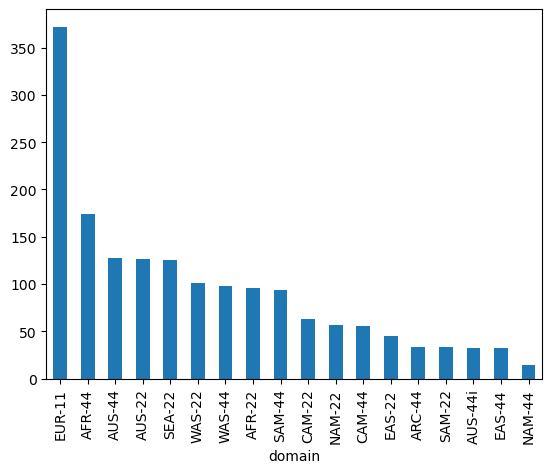

In [45]:
cordex_missing_df["domain"].value_counts().plot.bar()
plt.savefig("cordex-domains-missing-datasets-esgf.pdf", bbox_inches="tight")

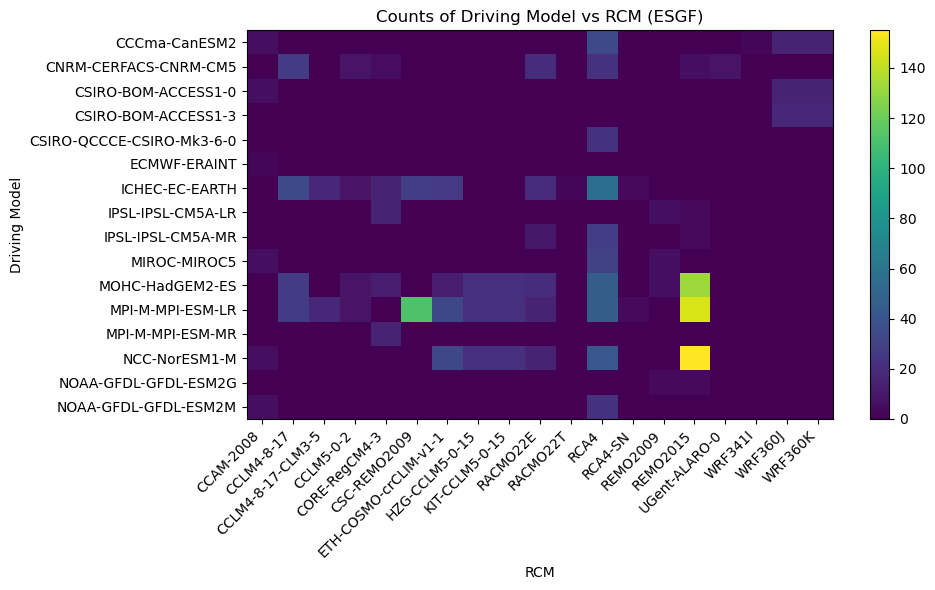

In [46]:
heatmap_data = (
    cordex_missing_df
    .groupby(["driving_model", "rcm_name"])
    .size()
    .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(10, 6))
cax = ax.imshow(heatmap_data, aspect='auto')

fig.colorbar(cax)
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=45, ha='right')
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
ax.set_xlabel("RCM")
ax.set_ylabel("Driving Model")
ax.set_title("Counts of Driving Model vs RCM (ESGF)")

plt.savefig("cordex-gcm-rcm-missing-datasets-esgf.pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()

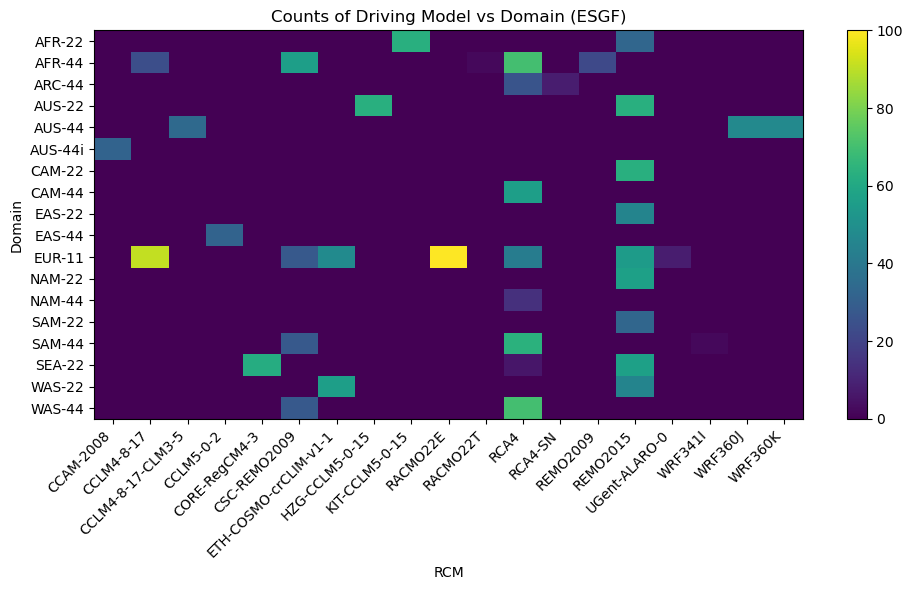

In [47]:
heatmap_data = (
    cordex_missing_df
    .groupby(["domain", "rcm_name"])
    .size()
    .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(10, 6))
cax = ax.imshow(heatmap_data, aspect='auto')

fig.colorbar(cax)
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=45, ha='right')
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
ax.set_xlabel("RCM")
ax.set_ylabel("Domain")
ax.set_title("Counts of Driving Model vs Domain (ESGF)")

plt.savefig("cordex-domain-rcm-missing-datasets-esgf.pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()

Same for the WDC.

In [48]:
names = {
    0: "project", 1: "output", 2: "domain", 3: "institute", 4: "driving_model", 5: "experiment",
    6: "member", 7: "rcm_name", 8: "rcm_version", 9: "frequency", 10: "variable", 11: "version",
}

cordex_missing = cordex_atlas[~cordex_atlas["instance_id"].isin(cordex_wdc["instance_id"].values)]
cordex_missing_df = cordex_missing["instance_id"].drop_duplicates().str.split(".", expand=True).rename(names, axis=1)

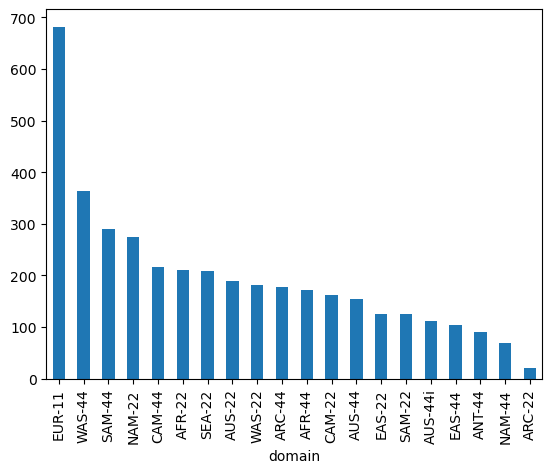

In [49]:
cordex_missing_df["domain"].value_counts().plot.bar()
plt.savefig("cordex-domains-missing-datasets-wdc.pdf", bbox_inches="tight")

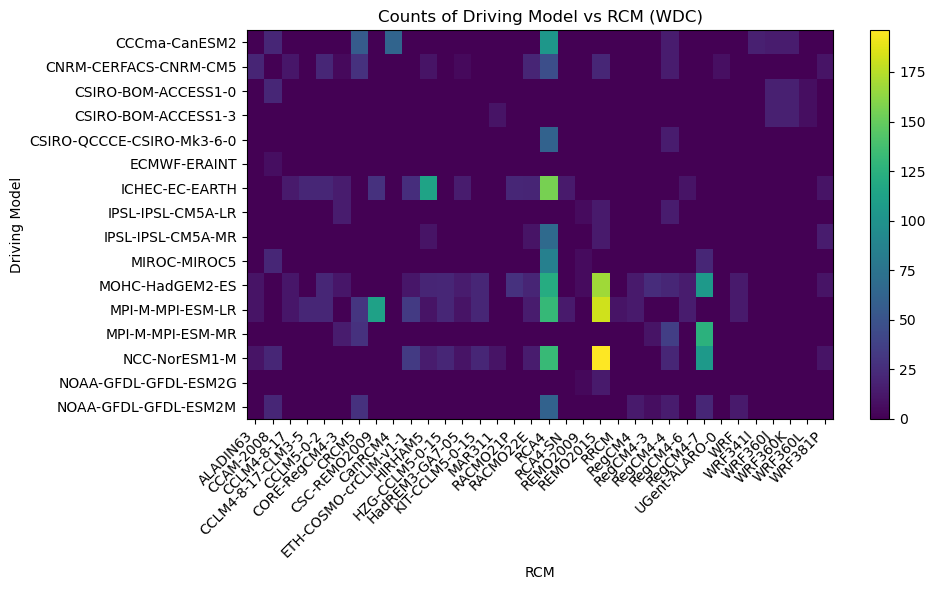

In [50]:
heatmap_data = (
    cordex_missing_df
    .groupby(["driving_model", "rcm_name"])
    .size()
    .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(10, 6))
cax = ax.imshow(heatmap_data, aspect='auto')

fig.colorbar(cax)
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=45, ha='right')
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
ax.set_xlabel("RCM")
ax.set_ylabel("Driving Model")
ax.set_title("Counts of Driving Model vs RCM (WDC)")

plt.savefig("cordex-gcm-rcm-missing-datasets-wdc.pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()

More statistics.

<Axes: xlabel='rcm_name'>

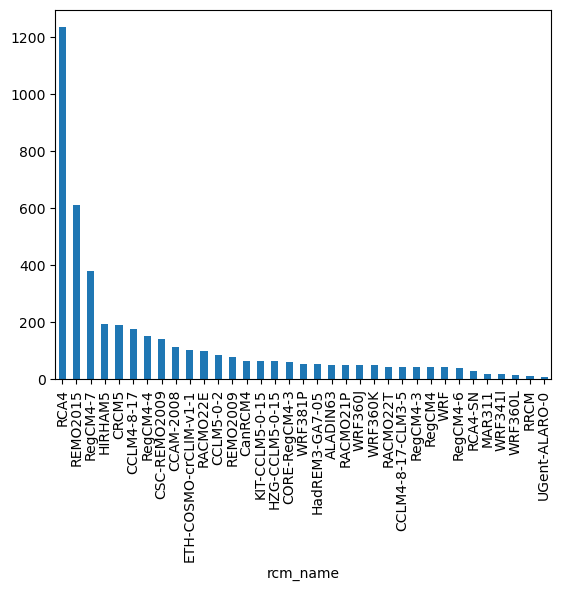

In [51]:
cordex_atlas["master_id"] = cordex_atlas["instance_id"].str.split(".", expand=True).iloc[:,:-1].agg(".".join, axis=1)
cordex_atlas_facets = cordex_atlas["master_id"].str.split(".", expand=True).rename({
    0: "project",
    1: "output",
    2: "domain",
    3: "institute",
    4: "driving_model",
    5: "experiment",
    6: "member",
    7: "rcm_name",
    8: "rcm_version",
    9: "frequency",
    10: "variable",
    }, axis=1)

cordex_atlas_facets["rcm_name"].value_counts().plot.bar()

In [52]:
cordex_atlas_facets[["driving_model", "institute", "rcm_name", "rcm_version", "variable", "domain", "experiment", "member", "frequency", "variable"]].groupby("rcm_name").nunique().sort_values("domain", ascending=False)

,driving_model,institute,rcm_version,variable,domain,experiment,member,frequency,variable
rcm_name,,,,,,,,,
REMO2015,7,1,2,7,9,4,2,2,7
RCA4,10,1,4,7,8,4,3,2,7
RegCM4-7,5,2,1,7,6,3,1,2,7
HIRHAM5,6,1,3,7,6,4,3,2,7
CSC-REMO2009,2,1,1,7,4,4,2,2,7
CRCM5,5,2,1,7,4,3,1,2,7
CanRCM4,1,1,1,7,3,3,1,2,7
RegCM4-3,3,1,1,5,2,3,1,1,5
RegCM4-4,8,2,2,7,2,4,1,2,7
